In [1]:
# Quantum system
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, Operator,DensityMatrix,state_fidelity,concurrence,entropy,negativity
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

from qiskit_dynamics import Solver,Signal


from qiskit import pulse
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize
import random
import sympy as sym 
import jax


jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

In [36]:
import numpy as np
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

def plot_statevector_probabilities_qudit(statevector, d=2):
    """
    Grafica probabilidades de un statevector de qudits.
    Usa etiquetas en base d (por defecto qubits: d=2).
    """
    probabilities = statevector.probabilities()
    dim = len(probabilities)
    
    # Número de qudits
    num_qudits = int(round(np.log(dim) / np.log(d)))
    
    # Etiquetas en base d (por ejemplo base=3 para qutrits)
    basis_states = []
    for i in range(dim):
        digits = np.base_repr(i, base=d).zfill(num_qudits)
        basis_states.append(f"|{digits}⟩")
    
    # Gráfico
    plt.figure(figsize=(12, 7))
    plt.bar(basis_states, probabilities, color='royalblue')
    plt.xlabel(f'Computational basis states ', fontsize=18)
    plt.ylabel('Probability', fontsize=18)
    # plt.title(f'Measurement Probabilities of {num_qudits} qudits (d={d})')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=0,fontsize=16)
    plt.yticks(fontsize=14)
    plt.grid(True, axis='y', linestyle='--', alpha=0.9)
    plt.tight_layout()
    plt.show()


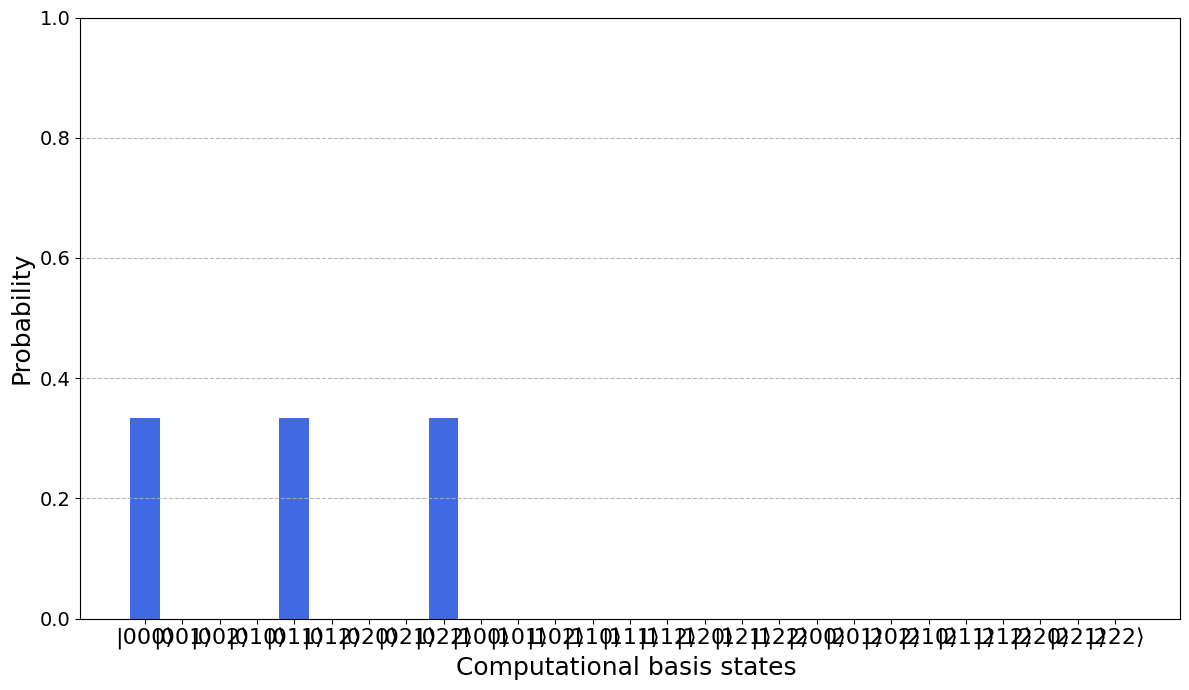

In [37]:
# Estado GHZ qutrit: (|000> + |111> + |222>) / sqrt(3)
coef = np.zeros(27, dtype=complex)
coef[0]  = 1/np.sqrt(3)   # |000>
coef[4]  = 1/np.sqrt(3)   # |111>
coef[8] = 1/np.sqrt(3)   # |222>
psi_ghz_qutrit = Statevector(coef)

# Graficar con etiquetas en base 3
plot_statevector_probabilities_qudit(psi_ghz_qutrit, d=3)


In [4]:
# Llamar fake backend
backend = FakeSherbrooke()

#configuracion de backend
propiedades = backend.properties()
configuracion = backend.configuration()


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9


v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)
print(v7, v8, v9)

4.755587722216812 4.812531480182586 4.637614165110824


In [5]:
print(delta7, delta8, delta9)
print(J78, J89)
print(r0, r1, r2)

-1.9540951675249636 -1.9688054129735373 -1.8387169285946419
0.012651918734551187 0.014172096168429698
0.39575797919595557 0.6501466069370565 0.3148551427122911


In [6]:
# Definir los operadores 
dim = 3
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 = np.kron(ident,np.kron(ident, N))
N1 = np.kron(ident,np.kron(N, ident))
N2 = np.kron(np.kron(N, ident),ident)

a0 = np.kron(ident,np.kron(ident, a))
a1 = np.kron(ident,np.kron(a, ident))
a2 = np.kron(np.kron(a, ident),ident)


a0dag = np.kron(ident,np.kron(ident, adag))
a1dag = np.kron(ident,np.kron(adag, ident))
a2dag = np.kron(np.kron(adag, ident),ident)

# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0+   delta7*(a0dag@a0dag@a0@a0)/2   + 2*np.pi*v8 * N1+   delta8*(a1dag@a1dag@a1@a1)/2   + 2*np.pi*v9* N2 + delta9*(a2dag@a2dag@a2@a2)/2  + J78*(a0dag @ a1 +  a0 @ a1dag) + J89*(a1dag @ a2 +  a1 @ a2dag)

# Hamiltonianos de controles
H_drive7 =  r0 * (a0 + a0dag)
H_drive8 =  r1 * (a1 + a1dag)
H_drive9 =  r2 * (a2 + a2dag)
  

y0 = Statevector([1,0,0]).tensor(Statevector([1,0,0])).tensor(Statevector([1,0,0]))
# y0  = Statevector.from_label("000")

In [7]:
# Solucionar la ecuación de Schrödinger
solver  = Solver(static_hamiltonian=static_ham,
                 hamiltonian_operators=[H_drive7, H_drive8, H_drive9,H_drive7,H_drive8],
                 hamiltonian_channels=["d0", "d1", "d2","u0","u1"],
                 channel_carrier_freqs= {"d0": v7, "d1": v8, "d2": v9, "u0": v8, "u1": v9},
                 dt=dt,
                 array_library="jax")


In [8]:
# pulsos
from qiskit import pulse

def esque_pul(params):
    """Create a pulse schedule for a Bell state.

    Args:
        params (list): A list containing the parameters for the Gaussian pulses.

    Returns:
        _type_: Sigma1, sigma2, duration1, duration2,sigma3, duration3,
        
        Corresponding to each Gaussian pulse respectively.
        
        dura1, sigma1: Parameters for the first Gaussian pulse
        
        dura2, sigma2: Parameters for the second Gaussian pulse
        
        dura3, sigma3: Parameters for the third Gaussian pulse.
        
        
    1st pulse on d0 and d1
    
    2nd pulse on u0
    
    dura1 > with1
    
    dura2 > with1
    
    dura3 > with3
    
    1st and 2nd pulse with the same width
    
    in this case with1 = 191.910934 and with3 = 797.242687
    
    Amplitudes are fixed based on previous optimizations.
    """
    dura1, sigma1, dura3, sigma3,  = params
    
    dura1 = int(dura1)
    dura2 = int(dura1)
    dura3 = int(dura3)
    sigma1 = int(sigma1)
    sigma2 = int(sigma1)
    sigma3 = int(sigma3)
    
    width1 =  191.910934
    width3 =  797.242687

    width1 = int(width1)
    width3 = int(width3)

    amp1  =  0.6824432988764655
    amp2  =  0.8286644926788276
    amp3  =  0.7868326972398657
    
    # dura = int(dura2/2)
   
    
    with pulse.build(name="pulse Bell") as bell:
        
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        

        # primer pulso en d0 y d1
        pulse.play(pulse.GaussianSquare(dura1, amp1, sigma1, width1), d0)
        pulse.play(pulse.GaussianSquare(dura2, amp2, sigma2, width1), d1)

        # pulso de control en u0
        pulse.delay(  dura1, u0)
        pulse.play(pulse.GaussianSquare(dura3, amp3, sigma3, width3), u0)
    
    return bell
        

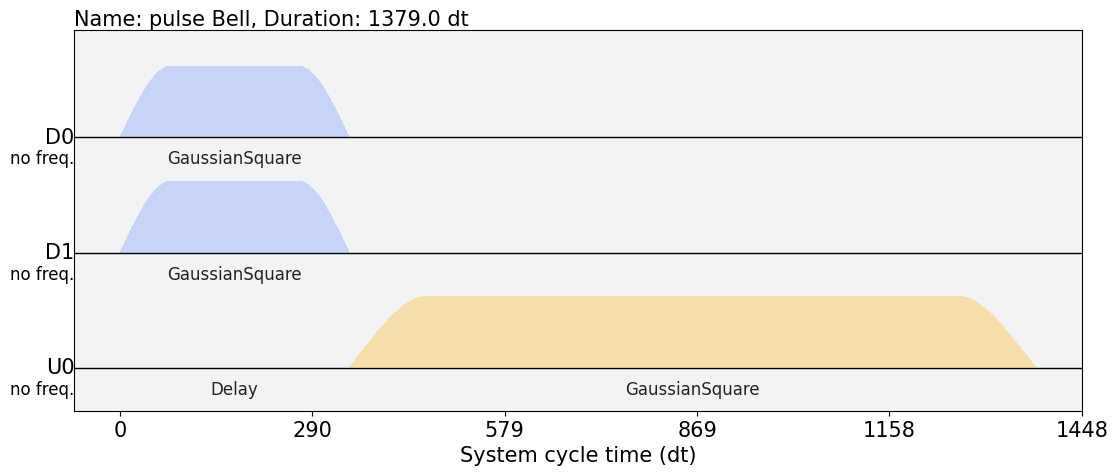

In [9]:
esque_pul([ 3.454e+02,  7.218e+01,  1.034e+03,  9.756e+01]).draw()


In [10]:
# fun_objetivo
def evo_bell(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    return yf


In [11]:
y = evo_bell([ 3.454e+02,  7.218e+01,  1.034e+03,  9.756e+01])

In [12]:
y.draw('latex')

<IPython.core.display.Latex object>

In [13]:
# fun_objetivo
def evo_bell_state(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])


    redu_vector = [] 
    for i in [0,1,3,4,9,10,12,13]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector)/np.linalg.norm(redu_vector)



    # rho_bc = partial_trace(Statevector(yr), [0])
    # rho_ac = partial_trace(Statevector(yr), [1])
    # rho_ab = partial_trace(Statevector(yr), [2])

    # cost = (negativity(rho_ab,[0]) - 0.5)**2
    return yr,yf

In [14]:
esta = evo_bell_state( [3.454e+02,  7.218e+01,  1.034e+03,  9.756e+01])


In [15]:
Statevector(esta[0]).draw('latex_source')

'(0.4475790733 + 0.2752650516 i) |000\\rangle+(0.1041931332 - 0.4604109091 i) |001\\rangle+(-0.4151285426 - 0.2411397412 i) |010\\rangle+(0.060618159 - 0.5164806845 i) |011\\rangle+(-0.0075230524 - 0.0035901854 i) |100\\rangle+(0.0001550959 - 0.009213213 i) |101\\rangle+(-0.0004469313 - 0.0018973346 i) |110\\rangle+(0.0012590534 - 0.0009959895 i) |111\\rangle'

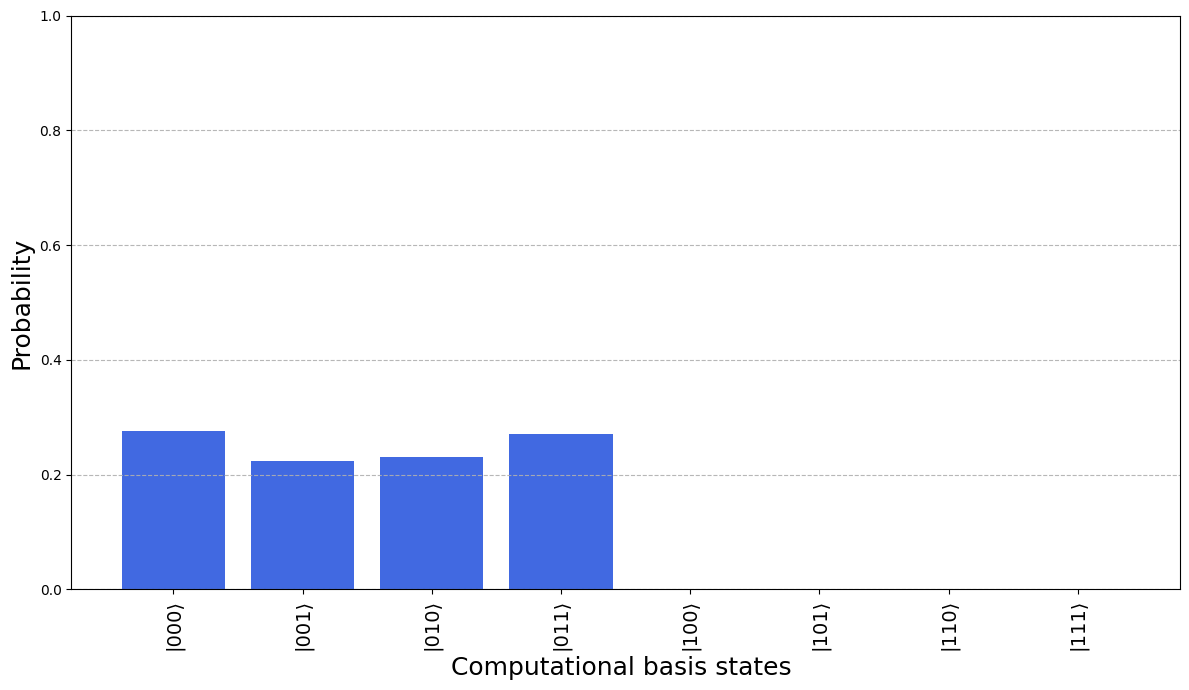

In [16]:
plot_statevector_probabilities_qudit(Statevector(esta[0]), d=2)

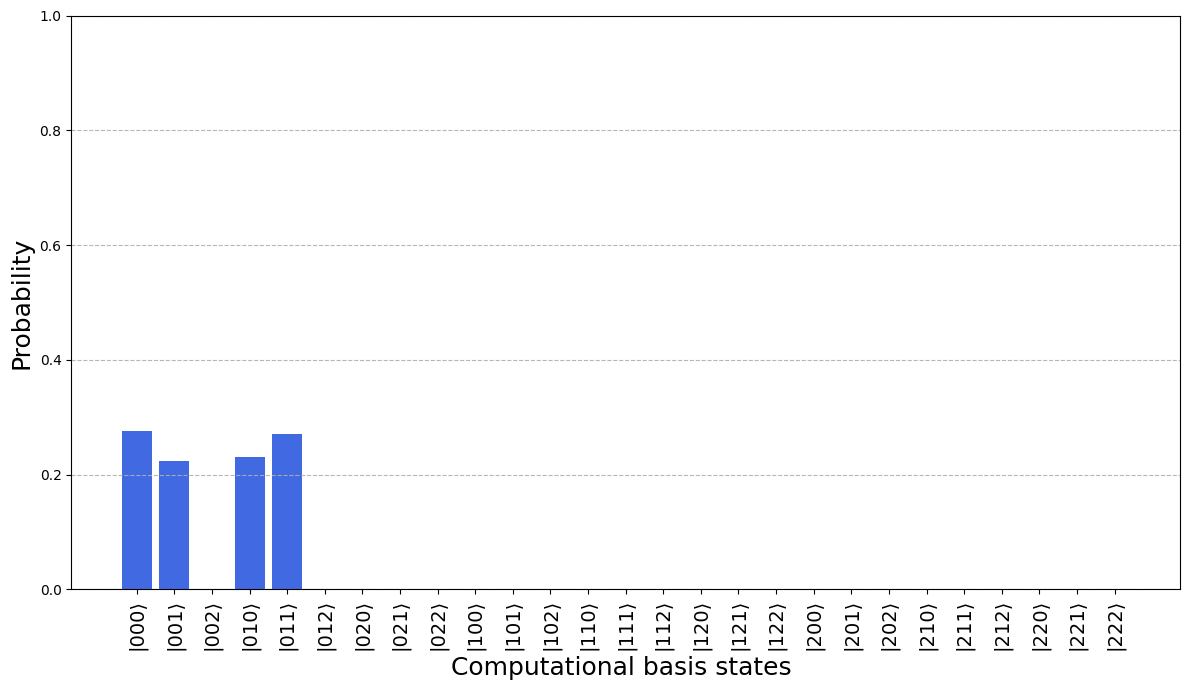

In [17]:
plot_statevector_probabilities_qudit(esta[1], d=3)

In [18]:
negativity(Statevector(esta[0]),[0])

np.float64(0.49955060504793425)

In [19]:
negativity(Statevector(esta[0]),[1])

np.float64(0.49955236599779973)

In [20]:
# fun_objetivo
def evo_bell_qubit(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])


    redu_vector = [] 
    for i in [0,1,3,4,9,10,12,13]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector)/np.linalg.norm(redu_vector)



    # rho_bc = partial_trace(Statevector(yr), [0])
    # rho_ac = partial_trace(Statevector(yr), [1])
    rho_ab = partial_trace(Statevector(yr), [2])

    cost = (negativity(rho_ab,[0]) -  0.5)**2 + (negativity(rho_ab,[1]) -  0.5)**2 
    return cost


In [21]:
s = evo_bell_qubit( [ 3.453e+02,  7.241e+01,  1.034e+03,  9.754e+01])

In [22]:
s

np.float64(7.377974060332606e-07)

In [23]:
def callback(xk):
    costo = evo_bell_qubit(xk)
    print(f"Current parameters: {xk}, Cost: {costo}")
    
x0 =  [ 3.453e+02,  7.241e+01,  1.034e+03,  9.754e+01]

bounds = [(200, 400), (40, 100), (800, 1200), (40, 100)]

# ---------- OPTIMIZACIÓN con L-BFGS-B ----------
result = minimize(
    fun= evo_bell_qubit,
    x0=x0,
    method='Nelder-Mead',
    bounds=bounds,
    callback=callback,
    options={
        'disp': True,
        'maxiter': 100,
        'ftol': 1e-10,
        'gtol': 1e-8,
        'maxls': 10  # máximo número de búsquedas de línea
    }
)

print("Resultado final:")
print(result)

C:\Users\PC\AppData\Local\Temp\ipykernel_27020\641721858.py:10: OptimizeWarning: Unknown solver options: ftol, gtol, maxls
  result = minimize(


Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Current parameters: [ 345.3    72.41 1034.     97.54], Cost: 7.377974060332606e-07
Curr

In [26]:
# Pulso GHZ

def esque_pul_GHZ(params):

    dura1, sigma1,    dura3, sigma3,    dura4, sigma4,     dura5, sigma5    = params

    dura1 = int(dura1)
    dura2 = int(dura1)
    dura3 = int(dura3)
    dura4 = int(dura4)
    dura5 = int(dura5)
    
    
    sigma1 = int(sigma1)
    sigma2 = int(sigma1)
    sigma3 = int(sigma3)
    sigma4 = int(sigma4) 
    sigma5 = int(sigma5)
    
    width1 =  200
    width3 =  1.500e+03
    width4 =  1.690e+02
    width5 =  1.500e+03

    width1 = int(width1)
    width3 = int(width3)
    width4 = int(width4)
    width5 = int(width5)
    
    amp1  =  4.90394435e-01
    amp2  =  -6.91612520e-01
    amp3  =   6.65492967e-01
    amp4  =   1.65200193e-01
    amp5  =   6.19735822e-01
    
    
    
    with pulse.build(name="ghz") as ghz:
        
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        d2 = pulse.DriveChannel(2)
        u1 = pulse.ControlChannel(1)
        

        # primer pulso en d0 y d1
        pulse.play(pulse.GaussianSquare(dura1, amp1, sigma1, width1), d0)
        pulse.play(pulse.GaussianSquare(dura2, amp2, sigma2, width1), d1)

        # pulso de control en u0
        pulse.delay( dura1 , u0)
        pulse.play(pulse.GaussianSquare(dura3, amp3, sigma3, width3), u0)
        
        # tercer pulso en d2
        pulse.delay(dura2 + dura3  , d2)
        pulse.play(pulse.GaussianSquare(dura4, amp4, sigma4, width4), d2)
        # cuarto pulso en u1
        
        pulse.delay(dura2 + dura3 + dura4, u1)
        pulse.play(pulse.GaussianSquare(dura5, amp5, sigma5, width5), u1)

    return ghz
    
    

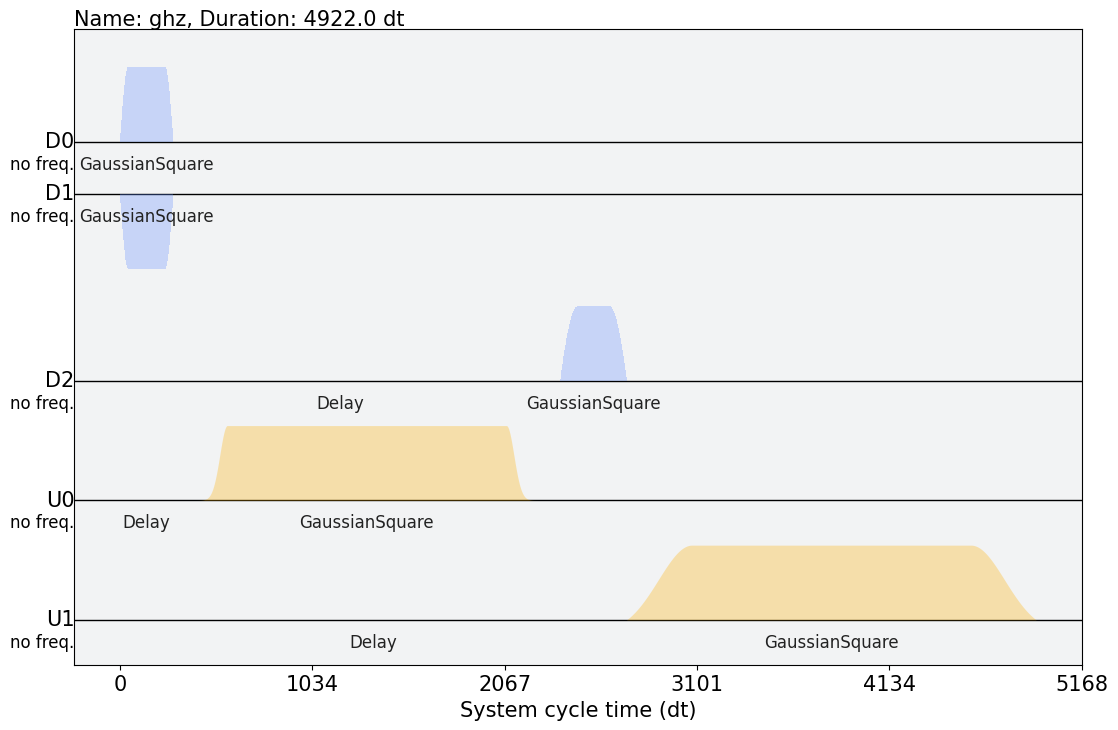

In [27]:
esque_pul_GHZ(  [ 286.40038164,   40.17608021, 2080.29798907,   40.44862187,  357.26695529,
  140.14826634, 2199.34944633,  180.        ]).draw()

In [28]:
# Pulso GHZ

def esque_pul_GHZ(params):

    # dura1, sigma1,    dura3, sigma3,    dura4, sigma4,     dura5, sigma5   = params
    sigma1,amp1,amp2,     sigma3,amp3,    sigma4,amp4 ,    sigma5,amp5   = params
    # amp1, amp2,     amp3,     amp4 ,    amp5   = params
    
    # sigma1 = 1.106e+02
    # sigma3 = 6.505e+01
    # sigma4 = 4.095e+01
    # sigma5 = 2.973e+02

    sigma1 = int(sigma1)
    sigma2 = int(sigma1)
    sigma3 = int(sigma3)
    sigma4 = int(sigma4) 
    sigma5 = int(sigma5)
    
    width1 =  191.910934
    width3 =  1.03750354e+03
    width4 =  1.68736170e+02
    width5 =  1.45046248e+03
     

    width1 = int(width1)
    width3 = int(width3)
    width4 = int(width4)
    width5 = int(width5)

    dura1 = width1 +  2*int(1*sigma1)
    dura2 = width1 +  2*int(1*sigma1)
    dura3 = width3 +  2*int(1*sigma3)
    dura4 = width4 +  2*int(1*sigma4)
    dura5 = width5 +  2*int(1*sigma5)

      

    # amp1  =   4.90394435e-01
    # amp2  =  -6.91612520e-01
    # amp3  =   6.65492967e-01
    # amp4  =   1.65200193e-01
    # amp5  =   6.19735822e-01
    
    
    
    with pulse.build(name="ghz") as ghz:
        
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        d2 = pulse.DriveChannel(2)
        u1 = pulse.ControlChannel(1)
        

        # primer pulso en d0 y d1
        pulse.play(pulse.GaussianSquare(dura1, amp1, sigma1, width1), d0)
        pulse.play(pulse.GaussianSquare(dura2, amp2, sigma2, width1), d1)

        # pulso de control en u0
        pulse.delay( dura1 , u0)
        pulse.play(pulse.GaussianSquare(dura3, amp3, sigma3, width3), u0)

        # tercer pulso en d2
        pulse.delay(dura2 + dura3  , d2)
        pulse.play(pulse.GaussianSquare(dura4, amp4, sigma4, width4), d2)
        # # cuarto pulso en u1
        
        pulse.delay(dura2 + dura3 + dura4, u1)
        pulse.play(pulse.GaussianSquare(dura5, amp5, sigma5, width5), u1)

    return ghz

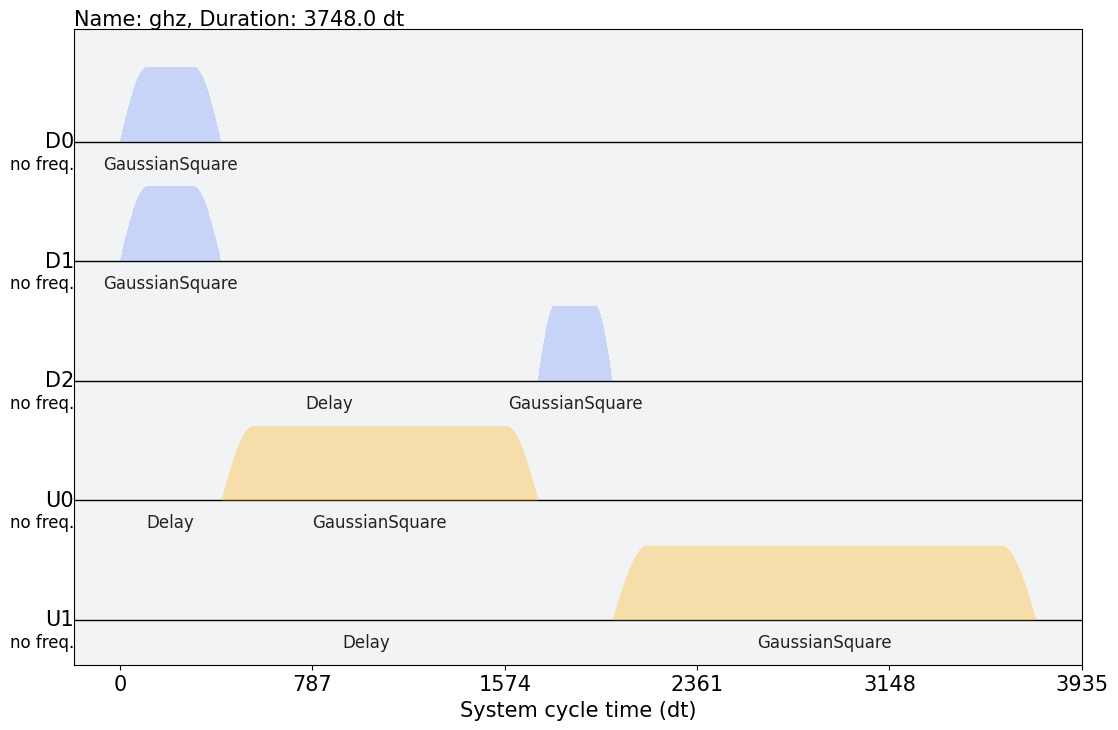

In [29]:
esque_pul_GHZ(   [111.40668999,   0.80939802,   0.27798819, 130.31892528,   0.69514675,
  68.31986628,   0.81862309, 142.62017516,   0.23133505]
).draw()


In [30]:
def three_t(yf):
    m1 = (yf[0] * yf[7])**2 + (yf[1] * yf[6])**2 + (yf[2] * yf[5])**2 + (yf[3] * yf[4])**2
    m2 = (yf[0] * yf[7] * yf[3] * yf[4] + yf[0] * yf[7] * yf[5] * yf[2] +
          yf[0] * yf[7] * yf[6] * yf[1] + yf[3] * yf[4] * yf[5] * yf[2] +
          yf[3] * yf[4] * yf[6] * yf[1] + yf[5] * yf[2] * yf[6] * yf[1])
    m3 = yf[0] * yf[6] * yf[5] * yf[3] + yf[7] * yf[1] * yf[2] * yf[4]
    tau =  4 * abs(m1 - 2 * m2 + 4 * m3)
    return tau


# fun_objetivo
def evo_ghz_qubit(x):
    signal = esque_pul_GHZ(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])


    redu_vector = [] 
    for i in [0,1,3,4,9,10,12,13]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector)/np.linalg.norm(redu_vector)



    # rho_bc = partial_trace(Statevector(yr), [0])
    # rho_ac = partial_trace(Statevector(yr), [1])
#     rho_ab = partial_trace(Statevector(yr), [2])

    # cost = - three_t(yr) 
    return yr


In [31]:
parametros_optimos = [
        109.6713004510977,
        69.46830060219426,
        115.19226526713393,
        199.61611337556684
    ]

parametros_optimos1 = [
        109.85495688859108,
        68.0474747925584,
        91.74319338165652,
        199.6213212505591
    ]

parametros_optimos2 = [
        110.1203406272805,
        66.07968330761528,
        65.99214073132873,
        199.1942630975941
    ]

parametros_optimos3 = [
        109.4965549557313,
        68.1369691804995,
        155.73873718239514,
        199.8950578203712
    ]

parametros_optimos4 = [
        110.71581065714739,
        67.37037913978733,
        131.00865104943514,
        199.48898440886717
    ]


parametros_optimos5 = [
        110.23365324551148,
        68.6378077254933,
        63.592157935718305,
        199.69873847886834
    ] 

amp =  [ 4.915e-01, -7.244e-01,  5.727e-01,  1.303e-01,  6.351e-01]

ghz = evo_ghz_qubit( [111.40668999,   0.80939802,   0.27798819, 130.31892528,   0.69514675,
  68.31986628,   0.81862309, 142.62017516,   0.23133505]
)


In [32]:
Statevector(ghz).draw('latex_source')

'(0.0548974233 + 0.0623543181 i) |000\\rangle+(0.1931124949 - 0.5356585218 i) |001\\rangle+(-0.3160025433 - 0.257741535 i) |010\\rangle+(0.0094258746 - 0.0585091946 i) |011\\rangle+(-0.010492372 + 0.0580099635 i) |100\\rangle+(0.3897090758 - 0.1166213743 i) |101\\rangle+(-0.0357939823 + 0.5672869107 i) |110\\rangle+(-0.077075853 + 0.0330144695 i) |111\\rangle'

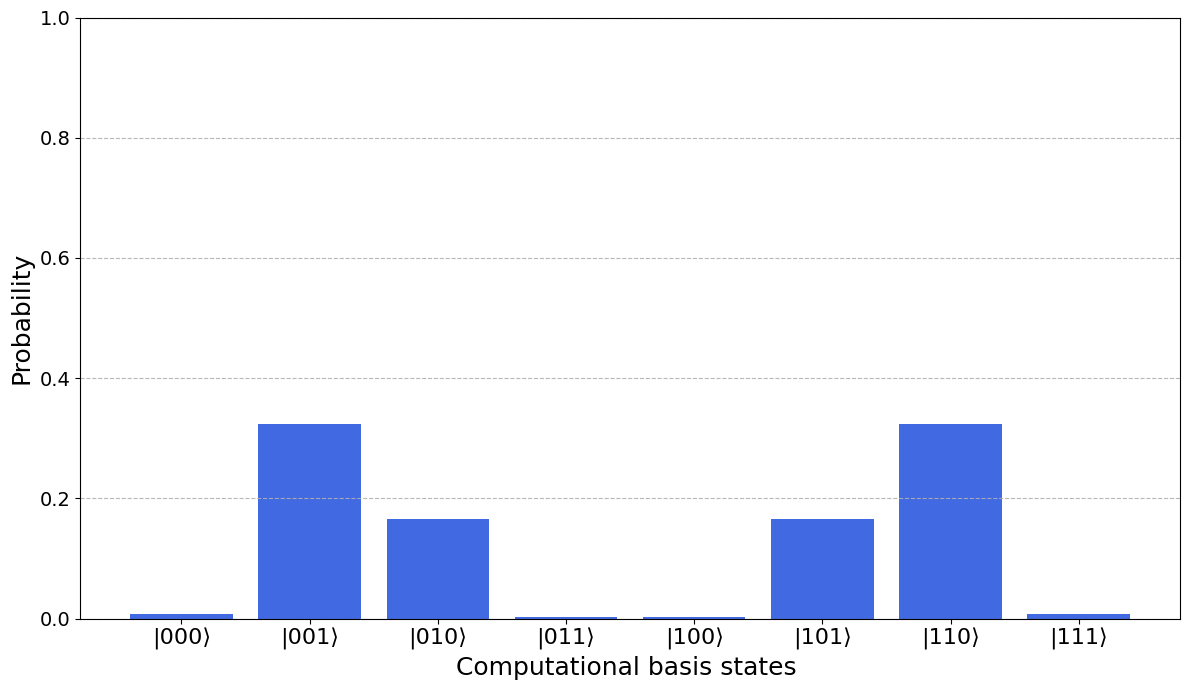

In [38]:
plot_statevector_probabilities_qudit(Statevector(ghz), d=2)


In [39]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
ghz_ideal = Statevector(qc).data
three_t(ghz_ideal)


np.float64(0.9999999999999996)

In [40]:
three_t(ghz) 

np.float64(0.9999212903673173)

In [41]:

def cost_ghz_qubit(x):
    signal = esque_pul_GHZ(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    redu_vector = [] 
    for i in [0,1,3,4,9,10,12,13]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector)/np.linalg.norm(redu_vector)
    
    t = yr/np.linalg.norm(yr)
    d1 = (t[0] * t[7])**2 + (t[1] * t[6])**2 + (t[2] * t[5])**2 + (t[3] * t[4])**2
    d2 = (t[0] * t[7] * t[3] * t[4] + t[0] * t[7] * t[5] * t[2] +
          t[0] * t[7] * t[6] * t[1] + t[3] * t[4] * t[5] * t[2] +
          t[3] * t[4] * t[6] * t[1] + t[5] * t[2] * t[6] * t[1])
    d3 =  (t[0] * t[6] * t[5] * t[3]) + (t[7] * t[1] * t[2] * t[4])
    tabc = 4 * abs(d1 - 2*d2 + 4*d3)
    
   
    return (1 - tabc)

In [38]:
def callback(xk):
    costo = cost_ghz_qubit(xk)
    print(f"Current parameters: {xk}, Cost: {costo}")

x0 =     [ 1.115e+02,  8.093e-01,  2.780e-01,  1.319e+02,  6.934e-01,
                  6.665e+01,  8.323e-01,  1.448e+02,  2.304e-01]


# with1 =  200
# with3 =  1.500e+03
# with4 =  1.690e+02
# with5 =  1.500e+03

bounds = [

    
    (100,200),
    (-1,1),
    (-1,1),
    (100,200),
    (-1,1),
    (60,200),    
    (-1,1),
    (100,200),
    (-1,1)
]

# ---------- OPTIMIZACIÓN con L-BFGS-B ----------
result = minimize(
    fun= cost_ghz_qubit,
    x0=x0,
    method='Nelder-Mead',
    bounds=bounds,
    callback=callback,
    options={
        'disp': True,
        'maxiter': 100,
        'ftol': 1e-10,
        # 'gtol': 1e-8,
        'maxls': 10  # máximo número de búsquedas de línea
    }
)

print("Resultado final:")
print(result)

C:\Users\PC\AppData\Local\Temp\ipykernel_110436\406243351.py:29: OptimizeWarning: Unknown solver options: ftol, maxls
  result = minimize(


KeyboardInterrupt: 

In [58]:
import numpy as np
from scipy.optimize import minimize

# ---------- CALLBACK ----------
def callback(xk):
    costo = cost_ghz_qubit(xk)
    print(f"Current parameters: {xk}, Cost: {costo}")

# ---------- PARÁMETROS INICIALES ----------
x0 =[ 2.739e+02,  4.814e+01,  1.129e+03,  7.613e+01,  2.620e+02,
                  8.243e+01,  2.200e+03,  2.000e+02]

# ---------- LIMITES ----------
bounds = [
    (200,360),
    (40,300),
    
    (1080,2200),
    (40,300),
    
    (200,360),
    (40,300),

    (1800,2200),
    (40,300)
]

# ---------- OPTIMIZACIÓN ----------
result = minimize(
    fun=cost_ghz_qubit,
    x0=x0,
    method='BFGS',   # Usa límites
    bounds=bounds,
    callback=callback,
    options={
        'disp': True,
        'maxiter': 500,
        'ftol': 1e-12
    }
)

# ---------- RESULTADO ----------
print("\n=== Resultado final ===")
print("Parámetros óptimos:", result.x)
print("Costo final:", result.fun)
print("Éxito:", result.success)
print("Mensaje:", result.message)


C:\Users\PC\AppData\Local\Temp\ipykernel_23736\1001167319.py:29: RuntimeWarning: Method BFGS cannot handle bounds.
  result = minimize(
C:\Users\PC\AppData\Local\Temp\ipykernel_23736\1001167319.py:29: OptimizeWarning: Unknown solver options: ftol
  result = minimize(


Optimization terminated successfully.
         Current function value: 0.015274
         Iterations: 0
         Function evaluations: 9
         Gradient evaluations: 1

=== Resultado final ===
Parámetros óptimos: [ 273.9    48.14 1129.     76.13  262.     82.43 2200.    200.  ]
Costo final: 0.015274146188576476
Éxito: True
Mensaje: Optimization terminated successfully.


In [ ]:
# pulso w  gaussian cuadrado

def esque_pul_w(params):
    # Pulso GHZ

    sigma1,amp1,amp2,amp3,  sigma4,amp4,amp5,amp6,  sigma7,amp7,amp8,amp9, sigma10,amp10,  sigma11,amp11, sigma12,amp12   = params
    # amp1, amp2,     amp3,     amp4 ,    amp5   = params
    
    # sigma1 = 1.106e+02
    # sigma3 = 6.505e+01
    # sigma4 = 4.095e+01
    # sigma5 = 2.973e+02

    sigma1 = int(sigma1)
    sigma2 = int(sigma1)
    sigma3 = int(sigma1)
    
    sigma4 = int(sigma4) 
    sigma5 = int(sigma4)
    sigma6 = int(sigma4)
    
    sigma7 = int(sigma7)
    sigma8 = int(sigma7)
    sigma9 = int(sigma7)
    
    sigma10 = int(sigma10)
    sigma11 = int(sigma11)
    sigma12 = int(sigma12)

    width1  =  2.34830783e+02
    width10 =  1.56574174e+03
    width4  =  1.87479735e+02
    width11 =  1.22942236e+03
    width7  =  2.74196599e+02
    width12 =  1.32352652e+03
    
  

    width1 = int(width1)
    width10 = int(width10)
    
    
    width4 = int(width4)
    width11 = int(width11)
    
    
    width7 = int(width7)
    width12 = int(width12)
    
    

    dura1 = width1 +  2*int(1*sigma1)
    dura2 = width1 +  2*int(1*sigma1)
    dura3 = width1 +  2*int(1*sigma1)
    
    dura10 = width10 +  2*int(1*sigma10)
    
    
    dura4 = width4 +  2*int(1*sigma4)
    dura5 = width4 +  2*int(1*sigma4)
    dura6 = width4 +  2*int(1*sigma4)
    
    dura11 = width11 +  2*int(1*sigma11)

    dura7 = width7 +  2*int(1*sigma7)
    dura8 = width7 +  2*int(1*sigma7)
    dura9 = width7 +  2*int(1*sigma7)
    
    dura12 = width12 +  2*int(1*sigma12)
    
    
      

    # amp1  =   4.90394435e-01
    # amp2  =  -6.91612520e-01
    # amp3  =   6.65492967e-01
    # amp4  =   1.65200193e-01
    # amp5  =   6.19735822e-01
    
    
    
    with pulse.build(name="w") as w:
        
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
        d2 = pulse.DriveChannel(2)
        u1 = pulse.ControlChannel(1)
        

        # primer pulso en d0 y d1
        pulse.play(pulse.GaussianSquare(dura1, amp1, sigma1, width1), d0)
        pulse.play(pulse.GaussianSquare(dura2, amp2, sigma2, width1), d1)
        pulse.play(pulse.GaussianSquare(dura3, amp3, sigma3, width1), d2)

        # pulso de control en u0
        pulse.delay( dura1 , u0)
        pulse.play(pulse.GaussianSquare(dura10, amp10, sigma10, width10), u0)

        # tercer pulso en d2
        pulse.delay(dura10  , d0)
        pulse.delay(dura10  , d1)
        pulse.delay(dura10  , d2)
        pulse.play(pulse.GaussianSquare(dura4, amp4, sigma4, width4), d0)
        pulse.play(pulse.GaussianSquare(dura5, amp5, sigma5, width4), d1)
        pulse.play(pulse.GaussianSquare(dura6, amp6, sigma6, width4), d2)
        # # # # cuarto pulso en u1
        
        pulse.delay(dura1 + dura10 + dura4, u1)
        pulse.play(pulse.GaussianSquare(dura11, amp11, sigma11, width11), u1)
        
        pulse.delay( dura11, d0)
        pulse.delay( dura11, d1)
        pulse.delay( dura11, d2)
        pulse.play(pulse.GaussianSquare(dura7, amp7, sigma7, width7), d0)
        pulse.play(pulse.GaussianSquare(dura8, amp8, sigma8, width7), d1)
        pulse.play(pulse.GaussianSquare(dura9, amp9, sigma9, width7), d2)

        pulse.delay(dura4 + dura11 +dura7, u0)
        pulse.play(pulse.GaussianSquare(dura12, amp12, sigma12, width12), u0)

    return w
  

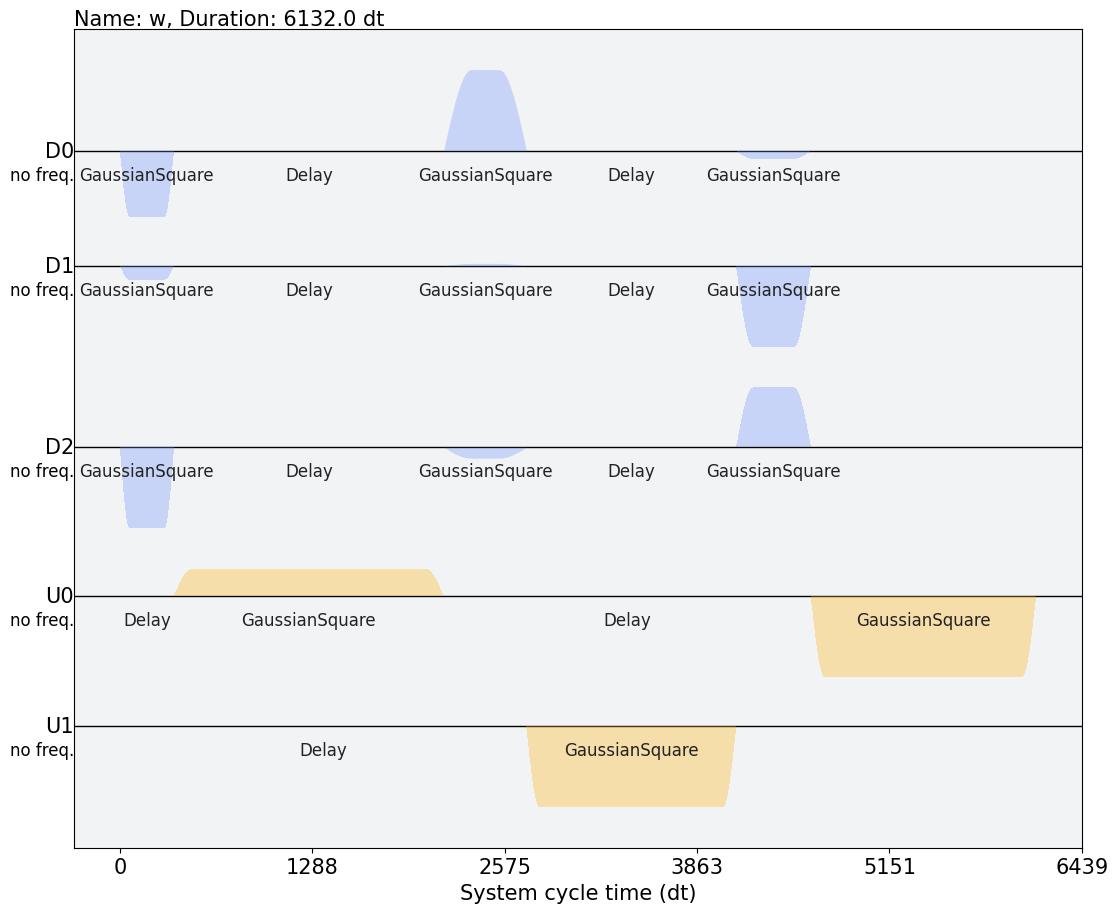

In [43]:
esque_pul_w([ 6.37831081e+01, -4.99757010e-01, -1.55218319e-01, -6.98213190e-01,
  1.83590195e+02,  6.12171915e-01,  2.56210429e-02, -9.38807900e-02,
  1.13576045e+02, -6.06957067e-02, -9.02406925e-01,  5.13976877e-01,
  1.21075949e+02,  2.23675901e-01,  8.86536829e+01, -7.99647178e-01,
  9.26112339e+01, -6.66675945e-01]).draw()


In [44]:
def cost_w_qubit(x):
    signal = esque_pul_w(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    redu_vector = [] 
    for i in [0,1,3,4,9,10,12,13]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector)/np.linalg.norm(redu_vector)
    yr = Statevector(yr)
    conc_01 = concurrence(partial_trace(yr, [2]))**2
    conc_02 = concurrence(partial_trace(yr, [1]))**2  
    conc_12 = concurrence(partial_trace(yr, [0]))**2
    conc_function = conc_01 + conc_02 + conc_12
    
    first_constrain = (conc_function - 4/3) ** 2
    eq_cond = (conc_01 - 0.444444) ** 2 + (0.44444 - conc_02) ** 2 + (conc_12 - 0.44444) ** 2
    
    cost_func = np.sqrt(first_constrain + 10*eq_cond)
    return cost_func

In [45]:
def evol_w_qubit(x):
    signal = esque_pul_w(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=y0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]/np.linalg.norm(sol.y[-1])
    redu_vector = [] 
    for i in [0,1,3,4,9,10,12,13]:
        redu_vector.append(yf[i])
    yr = np.array(redu_vector)/np.linalg.norm(redu_vector)
    yr = Statevector(yr)
    conc_01 = concurrence(partial_trace(yr, [2]))**2
    conc_02 = concurrence(partial_trace(yr, [1]))**2  
    conc_12 = concurrence(partial_trace(yr, [0]))**2
    conc_function = conc_01 + conc_02 + conc_12
    
    first_constrain = (conc_01 - 4/9) ** 2
    eq_cond = (conc_01 - conc_12) ** 2 + (conc_01 - conc_02) ** 2 + 10*(conc_12 - conc_02) ** 2
    
    cost_func = np.sqrt(first_constrain + eq_cond)
    
    return yr

In [46]:
cost_w_qubit([ 6.37831081e+01, -4.99757010e-01, -1.55218319e-01, -6.98213190e-01,
  1.83590195e+02,  6.12171915e-01,  2.56210429e-02, -9.38807900e-02,
  1.13576045e+02, -6.06957067e-02, -9.02406925e-01,  5.13976877e-01,
  1.21075949e+02,  2.23675901e-01,  8.86536829e+01, -7.99647178e-01,
  9.26112339e+01, -6.66675945e-01]
)

np.float64(0.08896212431615552)

In [47]:
cost_w_qubit([ 6.32890475e+01, -4.99743416e-01, -1.55425269e-01, -6.98508609e-01,
  1.83550840e+02,  6.12300918e-01,  2.57248045e-02, -9.51476427e-02,
  1.13871651e+02, -6.07213600e-02, -9.03488195e-01,  5.12825305e-01,
  1.21600583e+02,  2.24036219e-01,  8.84892382e+01, -7.99400796e-01,
  9.25366212e+01, -6.68805203e-01]
)

np.float64(0.08133945350223834)

In [48]:
cost_w_qubit( [ 6.33140614e+01, -4.99795710e-01, -1.55786941e-01, -6.90220814e-01,
  1.83510699e+02,  6.12882362e-01,  2.57410880e-02, -9.51743643e-02,
  1.13993029e+02, -6.07136137e-02, -9.05377473e-01,  4.97681806e-01,
  1.21707931e+02,  2.24084700e-01,  8.80048537e+01, -7.99211406e-01,
  9.26995669e+01, -6.71389048e-01]
 )


np.float64(0.058533931856046315)

In [74]:
from scipy.optimize import minimize
import numpy as np

def callback(xk):
    costo = cost_w_qubit(xk)
    print(f"Current parameters: {xk}, Cost: {costo}")

# Tu punto inicial (necesita ser verificado contra los bounds)
x0 = np.array( [ 6.33330628e+01, -4.99770045e-01, -1.56028015e-01, -6.87059200e-01,
  1.83369608e+02,  6.13012365e-01,  2.57376250e-02, -9.61405127e-02,
  1.13902638e+02, -6.08100015e-02, -9.05340651e-01,  4.97340627e-01,
  1.21759010e+02,  2.24520443e-01,  8.80125865e+01, -7.98677953e-01,
  9.29872143e+01, -6.74167710e-01])

# Verificar y ajustar x0 para que esté dentro de los bounds
def adjust_to_bounds(x, bounds):
    x_adjusted = np.copy(x)
    for i in range(len(x)):
        lower, upper = bounds[i]
        if x[i] < lower:
            x_adjusted[i] = lower
        elif x[i] > upper:
            x_adjusted[i] = upper
    return x_adjusted

# Ajustar x0 a los bounds
# x0_adjusted = adjust_to_bounds(x0, bounds)

bounds = [
    (60, 65), (-0.5, 0), (-0.3, -0.2), (-0.734, -0.64554),
    (180, 190), (0.5, 0.7), (0.0, 0.02), (-0.01, 0.00),
    (113, 120), (-0.07, 0.0), (-0.9, -0.7), (0.3, 0.5),
    (110, 125), (0.1, 0.3),
    (80,90 ), (-0.8, -0.6),
    (85, 93), (-0.7, -0.5)
]

# OPCIÓN 1: Usar L-BFGS-B (que sí soporta bounds)
# result = minimize(
#     fun=cost_w_qubit,
#     x0=x0,  # Usar el punto inicial ajustado
#     method='L-BFGS-B',
#     bounds=bounds,
#     callback=callback,
#     options={
#         'disp': True,
#         'maxiter': 150,
#         'ftol': 1e-10,
#         'gtol': 1e-8,
#         'maxls': 10
#     }
# )

# OPCIÓN 2: Si prefieres Nelder-Mead, quita los bounds
result = minimize(
    fun=cost_w_qubit,
    x0=x0,
    method='Nelder-Mead',
    callback=callback,
    options={
        'disp': True,
        'maxiter': 100,
        'xatol': 1e-8,
        'fatol': 1e-10
    }
)

print("Resultado final:")
print(result)
print(f"Parámetros óptimos: {result.x}")
print(f"Costo mínimo: {result.fun}")

Current parameters: [ 6.33330628e+01 -4.99770045e-01 -1.56028015e-01 -6.87059200e-01
  1.83369608e+02  6.13012365e-01  2.57376250e-02 -9.61405127e-02
  1.13902638e+02 -6.08100015e-02 -9.05340651e-01  4.97340627e-01
  1.21759010e+02  2.24520443e-01  8.80125865e+01 -7.98677953e-01
  9.29872143e+01 -6.74167710e-01], Cost: 0.05095461000858827
Current parameters: [ 6.33330628e+01 -4.99770045e-01 -1.56028015e-01 -6.87059200e-01
  1.83369608e+02  6.13012365e-01  2.57376250e-02 -9.61405127e-02
  1.13902638e+02 -6.08100015e-02 -9.05340651e-01  4.97340627e-01
  1.21759010e+02  2.24520443e-01  8.80125865e+01 -7.98677953e-01
  9.29872143e+01 -6.74167710e-01], Cost: 0.05095461000858827
Current parameters: [ 6.33330628e+01 -4.99770045e-01 -1.56028015e-01 -6.87059200e-01
  1.83369608e+02  6.13012365e-01  2.57376250e-02 -9.61405127e-02
  1.13902638e+02 -6.08100015e-02 -9.05340651e-01  4.97340627e-01
  1.21759010e+02  2.24520443e-01  8.80125865e+01 -7.98677953e-01
  9.29872143e+01 -6.74167710e-01], Cos

C:\Users\PC\AppData\Local\Temp\ipykernel_110436\3783542392.py:55: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(


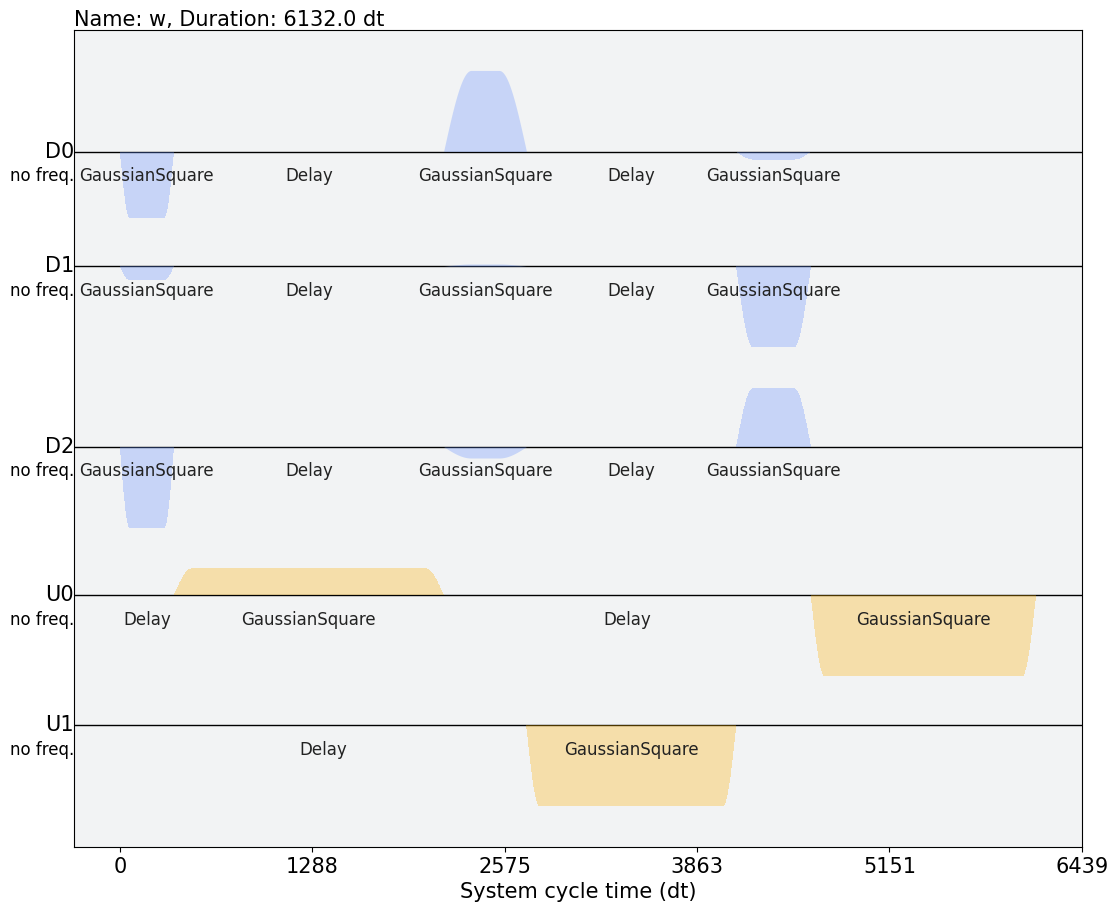

In [49]:
esque_pul_w( [ 6.33330628e+01, -4.99770045e-01, -1.56028015e-01, -6.87059200e-01,
  1.83369608e+02,  6.13012365e-01,  2.57376250e-02, -9.61405127e-02,
  1.13902638e+02, -6.08100015e-02, -9.05340651e-01,  4.97340627e-01,
  1.21759010e+02,  2.24520443e-01,  8.80125865e+01, -7.98677953e-01,
  9.29872143e+01, -6.74167710e-01]).draw()

In [50]:
w_op = evol_w_qubit([ 6.33330628e+01, -4.99770045e-01, -1.56028015e-01, -6.87059200e-01,
  1.83369608e+02,  6.13012365e-01,  2.57376250e-02, -9.61405127e-02,
  1.13902638e+02, -6.08100015e-02, -9.05340651e-01,  4.97340627e-01,
  1.21759010e+02,  2.24520443e-01,  8.80125865e+01, -7.98677953e-01,
  9.29872143e+01, -6.74167710e-01]
)


In [51]:
w_op.draw('latex_source')

'(0.0721809805 + 0.0153940039 i) |000\\rangle+(0.4413136053 - 0.0251241402 i) |001\\rangle+(0.2571692968 - 0.094443977 i) |010\\rangle+(-0.4101257074 + 0.3120861425 i) |011\\rangle+(-0.019074928 - 0.0525841299 i) |100\\rangle+(-0.1822897495 - 0.3282705161 i) |101\\rangle+(-0.3277610058 - 0.3733210332 i) |110\\rangle+(-0.2469472538 - 0.0812932767 i) |111\\rangle'

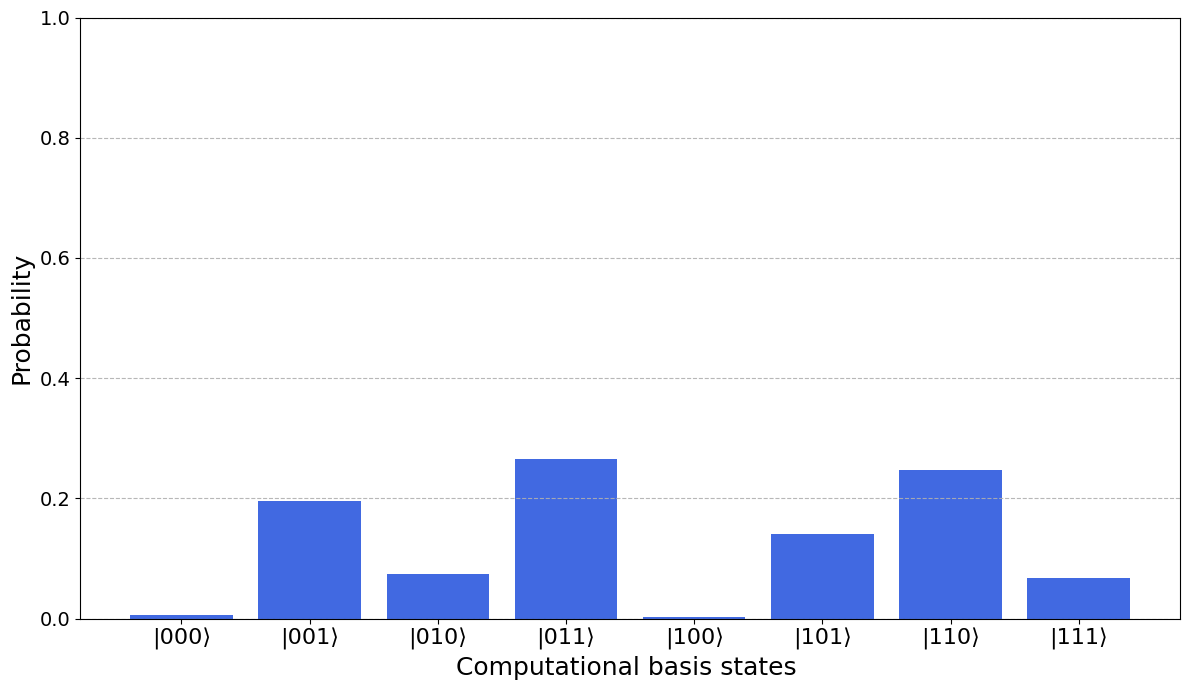

In [52]:
plot_statevector_probabilities_qudit(w_op, d=2)


In [72]:
conc_01 = concurrence(partial_trace(w_op, [2]))**2
conc_02 = concurrence(partial_trace(w_op, [1]))**2  
conc_12 = concurrence(partial_trace(w_op, [0]))**2
print(conc_01, conc_02, conc_12)

0.44132742055599544 0.4351191997537788 0.4339344646530573


In [51]:
w_opt = evol_w_qubit(  [ 6.33330628e+01, -4.99770045e-01, -1.56028015e-01, -6.87059200e-01,
  1.83369608e+02,  6.13012365e-01,  2.57376250e-02, -9.59905275e-02,
  1.13902638e+02, -6.08100015e-02, -9.05340651e-01,  4.97340627e-01,
  1.21759010e+02,  2.24520443e-01,  8.80125865e+01, -7.98677953e-01,
  9.29872143e+01, -6.74167710e-01]
)

In [52]:
conc_01 = concurrence(partial_trace(Statevector(w_opt), [2]))**2
conc_02 = concurrence(partial_trace(Statevector(w_opt), [1]))**2  
conc_12 = concurrence(partial_trace(Statevector(w_opt), [0]))**2
print(conc_01, conc_02, conc_12)

0.44127129926855485 0.43513798136804055 0.4339436418110444


In [1]:
width1  =  2.34830783e+02
width10 =  1.56574174e+03
width4  =  1.87479735e+02
width11 =  1.22942236e+03
width7  =  2.74196599e+02
width12 =  1.32352652e+03

In [2]:
sigma1 = 63.3330628 
sigma2 = 63.3330628
sigma3 = 63.3330628
sigma4 = 183.590195
sigma5 = 183.590195
sigma6 = 183.590195
sigma7 = 13.576045
sigma8 = 13.576045
sigma9 = 13.576045
sigma10 =  21.759010
sigma11 = 88.0125865
sigma12 = 92.9872143 


In [3]:
dura1 = width1 +  2*int(1*sigma1)
dura2 = width1 +  2*int(1*sigma1)
dura3 = width1 +  2*int(1*sigma1)
    
dura10 = width10 +  2*int(1*sigma10)
    
    
dura4 = width4 +  2*int(1*sigma4)
dura5 = width4 +  2*int(1*sigma4)
dura6 = width4 +  2*int(1*sigma4)
    
dura11 = width11 +  2*int(1*sigma11)

dura7 = width7 +  2*int(1*sigma7)
dura8 = width7 +  2*int(1*sigma7)
dura9 = width7 +  2*int(1*sigma7)
    
dura12 = width12 +  2*int(1*sigma12)

In [8]:
print(dura7, dura8, dura9, dura12)

300.196599 300.196599 300.196599 1507.52652
